<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37941 entries, 0 to 37940
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   t       37941 non-null  datetime64[ns]
 1   toy     37941 non-null  float64       
 2   p       37583 non-null  float64       
 3   Ws1     36645 non-null  float64       
 4   Wd1     36645 non-null  float64       
 5   T1      36645 non-null  float64       
 6   Ws2     36643 non-null  float64       
 7   Wd2     36643 non-null  float64       
 8   T2      36643 non-null  float64       
 9   Ws3     36641 non-null  float64       
 10  Wd3     36641 non-null  float64       
 11  T3      36641 non-null  float64       
dtypes: datetime64[ns](1), float64(11)
memory usage: 3.5 MB
None
                                   t           toy             p  \
count                          37941  37941.000000  37583.000000   
mean   2001-03-01 13:00:00.000000128    173.310703      4.912140   
min   

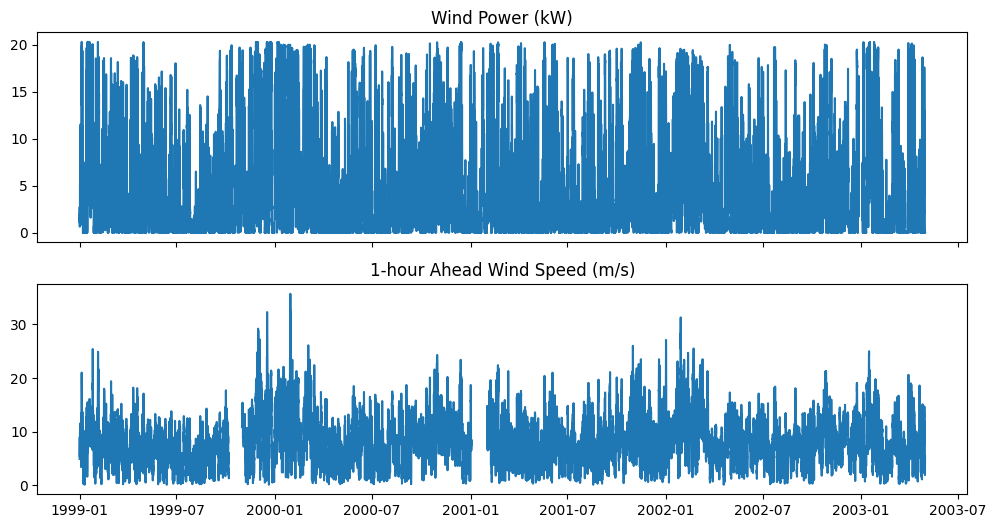

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
X = pd.read_csv("..\\data\\cex4WindDataInterpolated.csv", parse_dates=['t'])
print(X.info())
print(X.describe())

# Plot power and wind speed
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(X['t'], X['p'])
ax[0].set_title("Wind Power (kW)")
ax[1].plot(X['t'], X['Ws1'])
ax[1].set_title("1-hour Ahead Wind Speed (m/s)")
plt.show()


In [2]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(X['p'], order=(2,0,0))  # AR(2)
fit = model.fit()
print(fit.summary())


                               SARIMAX Results                                
Dep. Variable:                      p   No. Observations:                37941
Model:                 ARIMA(2, 0, 0)   Log Likelihood              -71386.227
Date:                Mon, 15 Dec 2025   AIC                         142780.454
Time:                        18:51:36   BIC                         142814.629
Sample:                             0   HQIC                        142791.299
                              - 37941                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.9126      0.203     24.249      0.000       4.516       5.310
ar.L1          1.1038      0.003    330.245      0.000       1.097       1.110
ar.L2         -0.1563      0.003    -52.918      0.0

In [3]:
import statsmodels.api as sm
import numpy as np

# Create lagged power
X['p_lag1'] = X['p'].shift(1)
X = X.dropna()

# Fit linear model
features = ['p_lag1', 'Ws1', 'Wd1', 'T1']
X_model = sm.add_constant(X[features])
model = sm.OLS(X['p'], X_model).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      p   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                 9.840e+04
Date:                Mon, 15 Dec 2025   Prob (F-statistic):               0.00
Time:                        18:51:37   Log-Likelihood:                -68443.
No. Observations:               36277   AIC:                         1.369e+05
Df Residuals:                   36272   BIC:                         1.369e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8957      0.398     -2.248      0.0

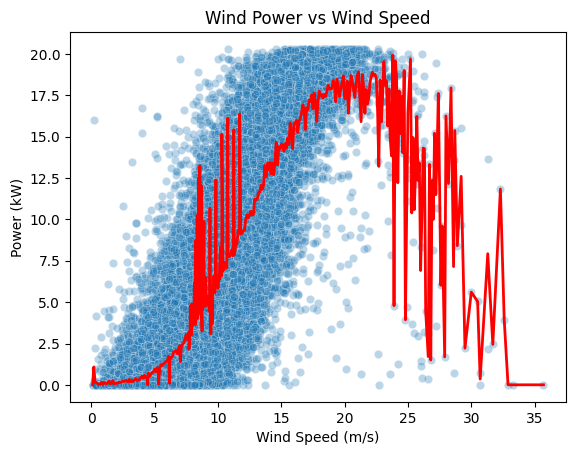

In [4]:
# Plot scatter and mean line
import seaborn as sns
sns.scatterplot(x='Ws1', y='p', data=X, alpha=0.3)
mean_by_ws = X.groupby('Ws1')['p'].mean().reset_index()
sns.lineplot(x='Ws1', y='p', data=mean_by_ws, color='red', linewidth=2)
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (kW)')
plt.title('Wind Power vs Wind Speed')
plt.show()


In [5]:
import numpy as np
import pandas as pd

# Define direction sectors
def wind_sector(deg):
    if (deg >= 315) or (deg < 45):
        return "N"
    elif 45 <= deg < 135:
        return "E"
    elif 135 <= deg < 225:
        return "S"
    else:
        return "W"

X["Wd_sector"] = X["Wd1"].apply(wind_sector)


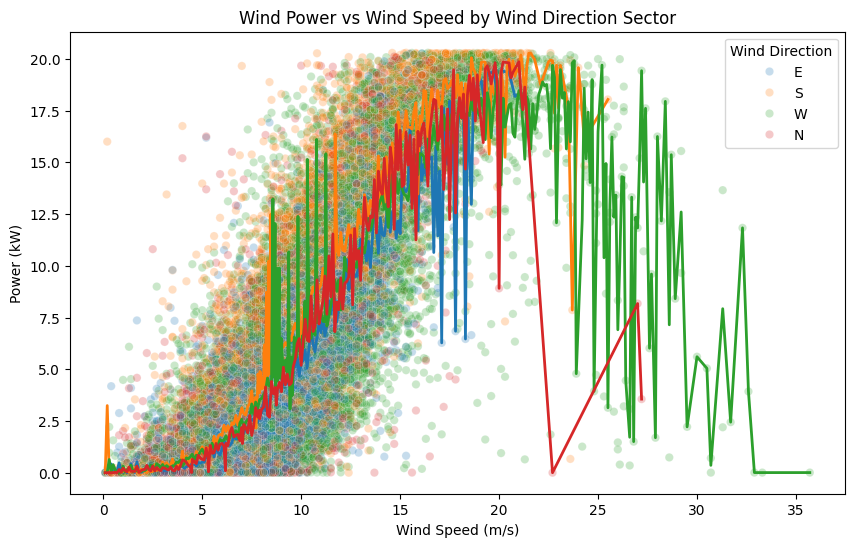

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=X,
    x="Ws1",
    y="p",
    hue="Wd_sector",
    alpha=0.25,
    palette="tab10"
)

# Mean curves per direction
for sector in X["Wd_sector"].unique():
    mean_curve = (
        X[X["Wd_sector"] == sector]
        .groupby("Ws1")["p"]
        .mean()
        .reset_index()
    )
    plt.plot(mean_curve["Ws1"], mean_curve["p"], linewidth=2)

plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Power (kW)")
plt.title("Wind Power vs Wind Speed by Wind Direction Sector")
plt.legend(title="Wind Direction")
plt.show()


In [11]:
# Outlier removal (power-based)
low_q = X["p"].quantile(0.01)
high_q = X["p"].quantile(0.99)

X_clean = X[(X["p"] >= low_q) & (X["p"] <= high_q)]


C:\Users\tamas\AppData\Local\Temp\ipykernel_6576\1255368665.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_clean["Wd_sector"] = X_clean["Wd1"].apply(wind_sector)


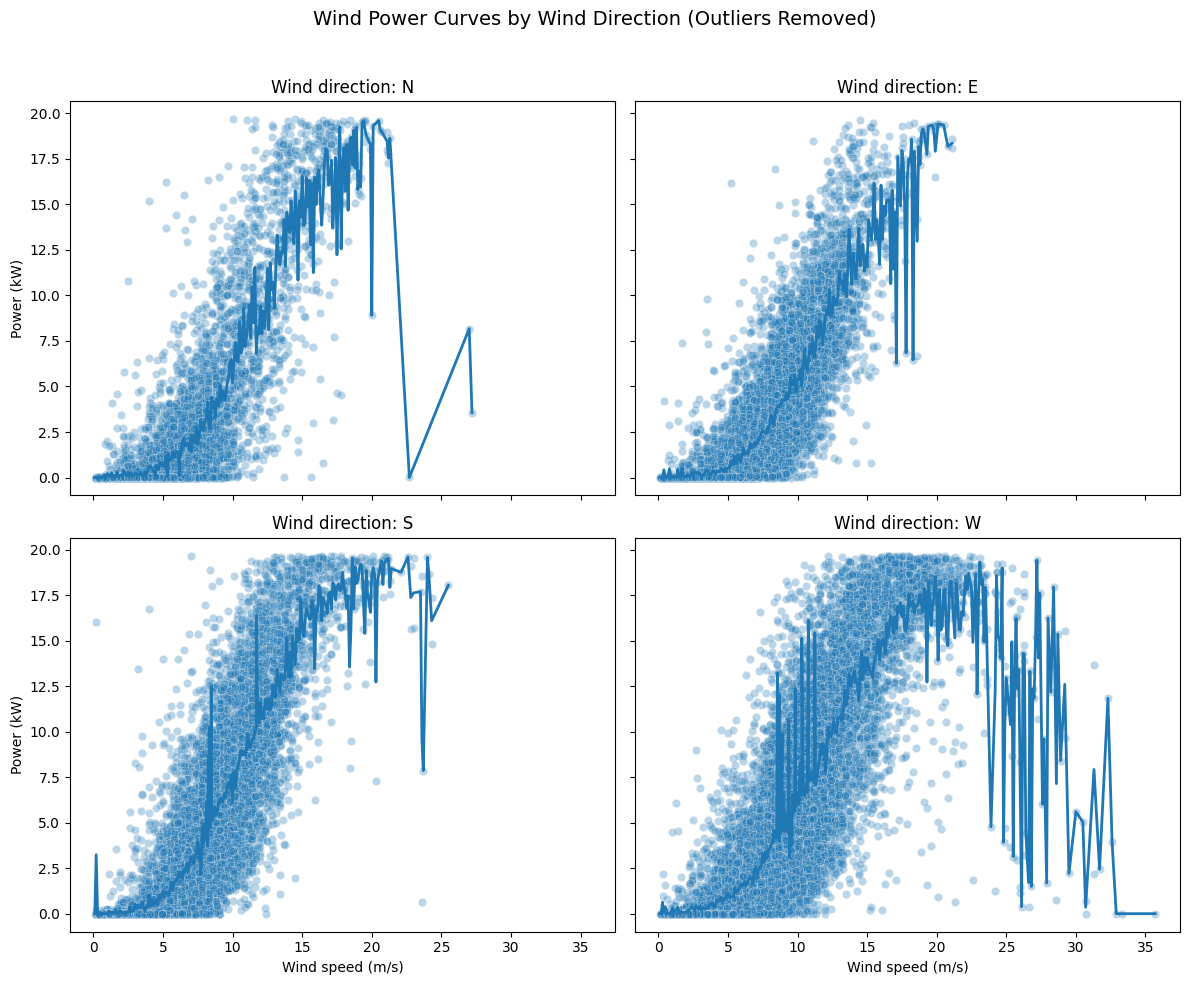

In [12]:
def wind_sector(deg):
    if (deg >= 315) or (deg < 45):
        return "N"
    elif 45 <= deg < 135:
        return "E"
    elif 135 <= deg < 225:
        return "S"
    else:
        return "W"

X_clean["Wd_sector"] = X_clean["Wd1"].apply(wind_sector)

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()

sectors = ["N", "E", "S", "W"]

for ax, sector in zip(axes, sectors):
    data_sec = X_clean[X_clean["Wd_sector"] == sector]

    # Scatter
    sns.scatterplot(
        data=data_sec,
        x="Ws1",
        y="p",
        alpha=0.3,
        ax=ax,
        legend=False
    )

    # Mean curve
    mean_curve = (
        data_sec.groupby("Ws1")["p"]
        .mean()
        .reset_index()
    )

    ax.plot(mean_curve["Ws1"], mean_curve["p"], linewidth=2)

    ax.set_title(f"Wind direction: {sector}")
    ax.set_xlabel("Wind speed (m/s)")
    ax.set_ylabel("Power (kW)")

plt.suptitle("Wind Power Curves by Wind Direction (Outliers Removed)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



In [7]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=3)
Ws_poly = poly.fit_transform(X[['Ws1']])
model_poly = LinearRegression().fit(Ws_poly, X['p'])


In [8]:
for k in [1, 2, 3]:
    features = [f'Ws{k}', f'Wd{k}', f'T{k}']
    X_model = sm.add_constant(X[features])
    model = sm.OLS(X['p'], X_model).fit()
    print(f"\n--- {k}-hour forecast model ---")
    print(model.summary())



--- 1-hour forecast model ---
                            OLS Regression Results                            
Dep. Variable:                      p   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.685
Method:                 Least Squares   F-statistic:                 2.632e+04
Date:                Mon, 15 Dec 2025   Prob (F-statistic):               0.00
Time:                        18:51:39   Log-Likelihood:                -92324.
No. Observations:               36277   AIC:                         1.847e+05
Df Residuals:                   36273   BIC:                         1.847e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.0470

C:\Users\tamas\AppData\Local\Temp\ipykernel_6576\3575196235.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  e_t = y_t - float(x_t.T @ theta)


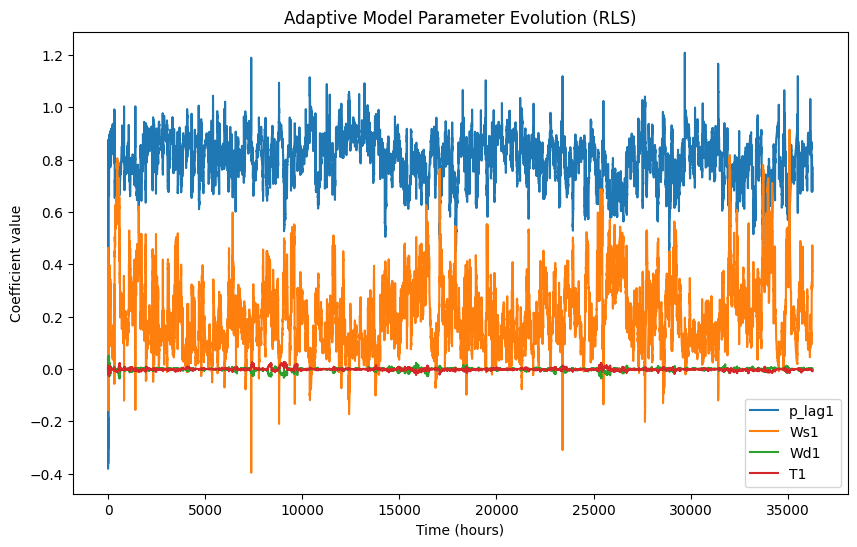

In [9]:
# Select inputs (1-hour horizon example)
features = ['p_lag1', 'Ws1', 'Wd1', 'T1']
y = X['p'].values
Xmat = X[features].values

# Recursive Least Squares (RLS) Implementation
def recursive_least_squares(X, y, lam=0.99, delta=1000):
    """
    lam   : forgetting factor (0 < lam <= 1)
    delta : initial covariance factor
    """
    n_samples, n_features = X.shape
    theta = np.zeros((n_features, 1))        # initial parameter vector
    P = delta * np.eye(n_features)           # covariance matrix
    theta_history = []

    for t in range(n_samples):
        x_t = X[t, :].reshape(-1, 1)
        y_t = y[t]

        # Kalman gain
        K = P @ x_t / (lam + x_t.T @ P @ x_t)
        # Prediction error
        e_t = y_t - float(x_t.T @ theta)
        # Update parameter vector
        theta = theta + K * e_t
        # Update covariance
        P = (P - K @ x_t.T @ P) / lam

        theta_history.append(theta.flatten())

    return np.array(theta_history)

# Run adaptive estimation
theta_trace = recursive_least_squares(Xmat, y, lam=0.98)

# Plot parameter evolution
plt.figure(figsize=(10,6))
for i, name in enumerate(features):
    plt.plot(theta_trace[:, i], label=name)
plt.title("Adaptive Model Parameter Evolution (RLS)")
plt.xlabel("Time (hours)")
plt.ylabel("Coefficient value")
plt.legend()
plt.show()


RMSE: 3.09


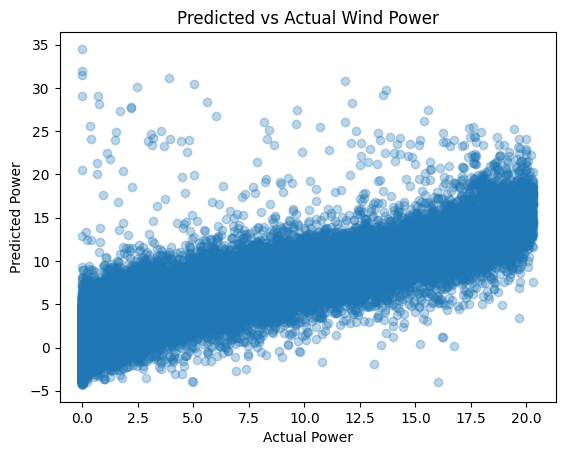

In [10]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_model)
rmse = np.sqrt(mean_squared_error(X['p'], y_pred))
print(f"RMSE: {rmse:.2f}")

plt.scatter(X['p'], y_pred, alpha=0.3)
plt.xlabel("Actual Power")
plt.ylabel("Predicted Power")
plt.title("Predicted vs Actual Wind Power")
plt.show()
